In [1]:
!pip -q install "monai[all]" nibabel pandas scikit-learn tqdm

import os, sys, time, glob, random
import numpy as np
import pandas as pd
import torch

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.3/53.3 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.9/80.9 MB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 95.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 131.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/

In [2]:
import os, json, time
from pathlib import Path

PROJECT_DIR = Path("/content/work_oasis")
OUT_DIR = PROJECT_DIR / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CFG = {
    "project_name": "OASIS_CDR_proxy_baseline",
    "seed": 42,
    "img_size": (128, 128, 128),
    "batch_size": 2,
    "num_workers": 2,
    "max_epochs": 10,
    "lr": 1e-4,
    "weight_decay": 1e-5,
    "label_rule": "label = (CDR > 0)",
    "positive_class": 1,
    "out_dir": str(OUT_DIR),
    "best_model_path": str(OUT_DIR / "best_model.pt"),
}

print("OUT_DIR:", CFG["out_dir"])

OUT_DIR: /content/work_oasis/outputs


In [3]:
summary_txt = f"""
Task: Cognitive impairment detection (proxy) using OASIS cross-sectional; label = (CDR > 0)

Model: MONAI DenseNet121 3D
Input size: {CFG["img_size"]}

Training:
epochs = {CFG["max_epochs"]}
batch_size = {CFG["batch_size"]}
lr = {CFG["lr"]}

Outputs saved to:
{CFG["out_dir"]}
"""

(Path(CFG["out_dir"]) / "README_results.txt").write_text(summary_txt)

print(summary_txt)
print("Saved:", str(Path(CFG["out_dir"]) / "README_results.txt"))


Task: Cognitive impairment detection (proxy) using OASIS cross-sectional; label = (CDR > 0)

Model: MONAI DenseNet121 3D
Input size: (128, 128, 128)

Training:
epochs = 10
batch_size = 2
lr = 0.0001

Outputs saved to:
/content/work_oasis/outputs

Saved: /content/work_oasis/outputs/README_results.txt


In [4]:
from google.colab import drive
drive.mount("/content/gdrive")

BASE_DIR = "/content/gdrive/MyDrive/Internship_MONAI/data_zips"  # <-- your screenshot folder
TAR_PATH = os.path.join(BASE_DIR, "oasis1_dataset.tar.gz")
CSV_PATH = os.path.join(BASE_DIR, "oasis_cross-sectional.csv")

WORK_DIR = "/content/work_oasis"
DATA_DIR = os.path.join(WORK_DIR, "oasis1_extracted")  # extraction destination
OUT_DIR  = os.path.join(WORK_DIR, "outputs")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

print("TAR:", TAR_PATH, os.path.exists(TAR_PATH))
print("CSV:", CSV_PATH, os.path.exists(CSV_PATH))
print("DATA_DIR:", DATA_DIR)

Mounted at /content/gdrive
TAR: /content/gdrive/MyDrive/Internship_MONAI/data_zips/oasis1_dataset.tar.gz True
CSV: /content/gdrive/MyDrive/Internship_MONAI/data_zips/oasis_cross-sectional.csv True
DATA_DIR: /content/work_oasis/oasis1_extracted


In [5]:
import tarfile

# Extract only once
marker = os.path.join(DATA_DIR, ".extracted_ok")
if not os.path.exists(marker):
    print("Extracting...", TAR_PATH)
    with tarfile.open(TAR_PATH, "r:gz") as tar:
        tar.extractall(DATA_DIR)
    with open(marker, "w") as f:
        f.write("ok")
    print("Done extracting.")
else:
    print("Already extracted.")

# Quick scan
nii_files = glob.glob(os.path.join(DATA_DIR, "**", "*.nii*"), recursive=True)
print("Found NIfTI files:", len(nii_files))
print("Example:", nii_files[0] if len(nii_files)>0 else "None")

Extracting... /content/gdrive/MyDrive/Internship_MONAI/data_zips/oasis1_dataset.tar.gz


/tmp/ipykernel_9884/2533004272.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_DIR)


Done extracting.
Found NIfTI files: 436
Example: /content/work_oasis/oasis1_extracted/oasis1_nifti_mpr1/OAS1_0263_MR1_mpr-1_anon.nii.gz


In [6]:
df = pd.read_csv(CSV_PATH, sep=";")

# Robust numeric conversion (handles commas)
def to_float(x):
    if pd.isna(x):
        return np.nan
    s = str(x).strip().replace(",", ".")
    try:
        return float(s)
    except:
        return np.nan

# OASIS: CDR is dementia severity. Simple binary task:
# label=1 if CDR > 0, else 0.
df["CDR_num"] = df["CDR"].apply(to_float)
df["label"] = df["CDR_num"].fillna(0.0).apply(lambda v: 1 if v > 0 else 0).astype(int)

print(df.columns.tolist())
print(df[["ID", "CDR", "CDR_num", "label"]].head())
print("Label counts:\n", df["label"].value_counts(dropna=False))

['ID', 'M/F', 'Hand', 'Age', 'Educ', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF', 'Delay', 'CDR_num', 'label']
              ID  CDR  CDR_num  label
0  OAS1_0001_MR1    0      0.0      0
1  OAS1_0002_MR1    0      0.0      0
2  OAS1_0003_MR1  0,5      0.5      1
3  OAS1_0004_MR1  NaN      NaN      0
4  OAS1_0005_MR1  NaN      NaN      0
Label counts:
 label
0    336
1    100
Name: count, dtype: int64


In [7]:
# Helper: find a subject ID inside a filepath
# OASIS filenames often include "OAS1_XXXX_MR1" etc.
def extract_oas_id(path: str):
    base = os.path.basename(path)
    # Try common patterns
    # Example: OAS1_0001_MR1_mpr-1_anon.nii.gz
    for token in base.split("_"):
        if token.startswith("OAS") or token.startswith("OAS1"):
            # sometimes token is OAS1, sometimes OAS1-0001...
            pass
    # Best simple approach: search full path for "OAS1_####"
    import re
    m = re.search(r"(OAS1_\d{4})", path)
    return m.group(1) if m else None

# Build mapping from subject ID -> label (from CSV)
# CSV often has column "ID" like "OAS1_0001_MR1" or similar.
# We'll normalize to "OAS1_####"
def normalize_id(raw):
    import re
    s = str(raw)
    m = re.search(r"(OAS1_\d{4})", s)
    return m.group(1) if m else None

df["ID_norm"] = df["ID"].apply(normalize_id)
id_to_label = {k: int(v) for k, v in df.dropna(subset=["ID_norm"]).set_index("ID_norm")["label"].to_dict().items()}

print("Subjects with labels:", len(id_to_label))

# Collect images and pair them with labels
pairs = []
missing_label = 0
missing_id = 0

nii_files = glob.glob(os.path.join(DATA_DIR, "**", "*.nii*"), recursive=True)
for p in nii_files:
    sid = extract_oas_id(p)
    if sid is None:
        missing_id += 1
        continue
    if sid not in id_to_label:
        missing_label += 1
        continue
    pairs.append({"image": p, "label": id_to_label[sid], "sid": sid})

print("Total images found:", len(nii_files))
print("Paired samples:", len(pairs))
print("Missing ID in filename:", missing_id)
print("Missing label in CSV:", missing_label)

# Quick sanity
print("Example pair:", pairs[0] if len(pairs)>0 else None)

Subjects with labels: 416
Total images found: 436
Paired samples: 436
Missing ID in filename: 0
Missing label in CSV: 0
Example pair: {'image': '/content/work_oasis/oasis1_extracted/oasis1_nifti_mpr1/OAS1_0263_MR1_mpr-1_anon.nii.gz', 'label': 1, 'sid': 'OAS1_0263'}


In [8]:
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

labels = [d["label"] for d in pairs]
train_data, val_data = train_test_split(
    pairs,
    test_size=0.2,
    random_state=SEED,
    stratify=labels
)

print("Train:", len(train_data), "Val:", len(val_data))
print("Train label counts:", np.bincount([d["label"] for d in train_data]))
print("Val label counts:", np.bincount([d["label"] for d in val_data]))

Train: 348 Val: 88
Train label counts: [268  80]
Val label counts: [68 20]


In [9]:
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    ScaleIntensityRanged,
    CropForegroundd,
    Resized,
    RandFlipd,
    RandAffined,
    EnsureTyped,
)

# Quality/robustness oriented defaults
train_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    Spacingd(keys=["image"], pixdim=(1.5,1.5,1.5), mode=("bilinear",)),
    CropForegroundd(keys=["image"], source_key="image"),
    ScaleIntensityRanged(keys=["image"], a_min=0, a_max=3000, b_min=0.0, b_max=1.0, clip=True),
    Resized(keys=["image"], spatial_size=(128,128,128)),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=2),
    RandAffined(
        keys=["image"],
        prob=0.2,
        rotate_range=(0.05,0.05,0.05),
        scale_range=(0.05,0.05,0.05),
        mode=("bilinear",),
        padding_mode="border",
    ),
    EnsureTyped(keys=["image","label"]),
])

val_transforms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    Spacingd(keys=["image"], pixdim=(1.5,1.5,1.5), mode=("bilinear",)),
    CropForegroundd(keys=["image"], source_key="image"),
    ScaleIntensityRanged(keys=["image"], a_min=0, a_max=3000, b_min=0.0, b_max=1.0, clip=True),
    Resized(keys=["image"], spatial_size=(128,128,128)),
    EnsureTyped(keys=["image","label"]),
])

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


In [10]:
from monai.data import CacheDataset, DataLoader

# Cache: good speed without re-reading NIfTI each epoch
cache_rate = 0.6  # if RAM allows, increase to 1.0
num_workers = 2

train_ds = CacheDataset(data=train_data, transform=train_transforms, cache_rate=cache_rate, num_workers=num_workers)
val_ds   = CacheDataset(data=val_data,   transform=val_transforms,   cache_rate=cache_rate, num_workers=num_workers)

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=num_workers, pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(val_ds,   batch_size=2, shuffle=False, num_workers=num_workers, pin_memory=torch.cuda.is_available())

batch = next(iter(train_loader))
print(batch["image"].shape, batch["label"])

Loading dataset: 100%|██████████| 52/52 [00:12<00:00,  4.26it/s]


torch.Size([2, 1, 128, 128, 128]) metatensor([1, 1])


In [11]:
from monai.networks.nets import DenseNet121
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = DenseNet121(
    spatial_dims=3,
    in_channels=1,
    out_channels=2
).to(device)

# Class weights from train set (avoid hardcoding)
cnt = Counter([d["label"] for d in train_data])
w0 = 1.0
w1 = cnt[0] / max(cnt[1], 1)
class_weights = torch.tensor([w0, w1], dtype=torch.float32).to(device)

loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

print("Train counts:", cnt, "weights:", class_weights.detach().cpu().numpy())

Device: cuda
Train counts: Counter({0: 268, 1: 80}) weights: [1.   3.35]


In [12]:
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, accuracy_score

scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

def run_eval():
    model.eval()
    y_true, y_prob, y_pred = [], [], []
    with torch.no_grad():
        for batch in val_loader:
            x = batch["image"].to(device)
            y = batch["label"].long().to(device)  # <-- prevents dtype issues
            with torch.amp.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
                logits = model(x)
                prob1 = torch.softmax(logits, dim=1)[:, 1]
                pred = torch.argmax(logits, dim=1)
            y_true.extend(y.detach().cpu().numpy().tolist())
            y_prob.extend(prob1.detach().cpu().numpy().tolist())
            y_pred.extend(pred.detach().cpu().numpy().tolist())

    auc = roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else float("nan")
    acc = accuracy_score(y_true, y_pred)
    return auc, acc

max_epochs = 10
best_auc = -1.0
best_path = os.path.join(OUT_DIR, "best_model.pt")

history = {"epoch": [], "train_loss": [], "val_auc": [], "val_acc": []}

for epoch in range(1, max_epochs + 1):
    model.train()
    epoch_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{max_epochs}")
    for batch in pbar:
        x = batch["image"].to(device)
        y = batch["label"].long().to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
            logits = model(x)
            loss = loss_fn(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = epoch_loss / max(1, len(train_loader))
    auc, acc = run_eval()

    history["epoch"].append(epoch)
    history["train_loss"].append(float(avg_loss))
    history["val_auc"].append(float(auc) if auc == auc else float("nan"))
    history["val_acc"].append(float(acc))

    print(f"[Epoch {epoch}] loss={avg_loss:.4f} val_auc={auc:.4f} val_acc={acc:.4f}")

    if auc == auc and auc > best_auc:  # auc==auc checks not NaN
        best_auc = auc
        torch.save({"model": model.state_dict(), "epoch": int(epoch), "val_auc": float(auc)}, best_path)
        print("   Saved best:", best_path)

Epoch 1/10: 100%|██████████| 174/174 [01:00<00:00,  2.87it/s, loss=1.7458]


[Epoch 1] loss=0.6019 val_auc=0.8529 val_acc=0.8068
   Saved best: /content/work_oasis/outputs/best_model.pt


Epoch 2/10: 100%|██████████| 174/174 [00:58<00:00,  2.98it/s, loss=0.2729]


[Epoch 2] loss=0.5462 val_auc=0.9088 val_acc=0.7955
   Saved best: /content/work_oasis/outputs/best_model.pt


Epoch 3/10: 100%|██████████| 174/174 [00:57<00:00,  3.01it/s, loss=1.6674]


...

[Epoch 8] loss=0.4917 val_auc=0.8375 val_acc=0.7955


Epoch 9/10: 100%|██████████| 174/174 [00:59<00:00,  2.91it/s, loss=0.4430]


[Epoch 9] loss=0.4737 val_auc=0.8691 val_acc=0.7841


Epoch 10/10: 100%|██████████| 174/174 [00:57<00:00,  3.02it/s, loss=1.6637]


[Epoch 10] loss=0.4839 val_auc=0.9000 val_acc=0.7955


In [13]:
ckpt = torch.load(best_path, map_location=device)
model.load_state_dict(ckpt["model"])
print("Loaded best epoch:", ckpt["epoch"], "best AUC:", ckpt["val_auc"])

auc, acc = run_eval()
print("Final Val AUC:", auc, "Final Val Acc:", acc)

Loaded best epoch: 2 best AUC: 0.9088235294117646
Final Val AUC: 0.9088235294117646 Final Val Acc: 0.7954545454545454


Saved: /content/work_oasis/outputs/training_history.csv


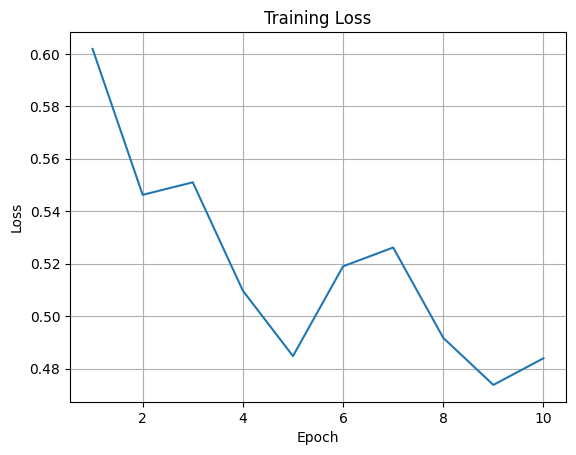

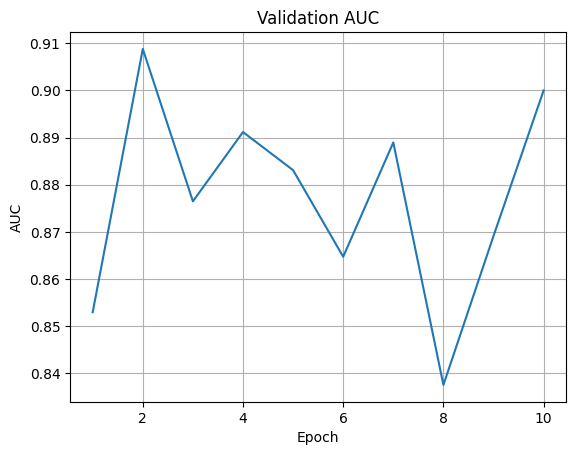

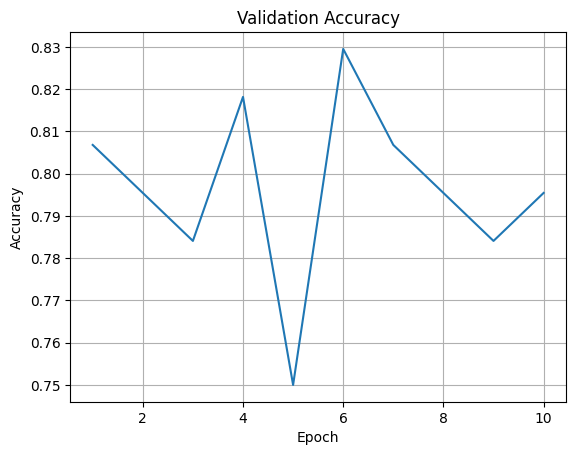

In [14]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# save metrics once
hist_df = pd.DataFrame(history)
csv_out = os.path.join(OUT_DIR, "training_history.csv")
hist_df.to_csv(csv_out, index=False)
print("Saved:", csv_out)

def save_plot(x, y, title, ylab, filename):
    plt.figure()
    plt.plot(x, y)
    plt.xlabel("Epoch")
    plt.ylabel(ylab)
    plt.title(title)
    plt.grid(True)
    plt.savefig(os.path.join(OUT_DIR, filename), dpi=200, bbox_inches="tight")
    plt.show()

save_plot(hist_df["epoch"], hist_df["train_loss"], "Training Loss", "Loss", "curve_train_loss.png")
save_plot(hist_df["epoch"], hist_df["val_auc"], "Validation AUC", "AUC", "curve_val_auc.png")
save_plot(hist_df["epoch"], hist_df["val_acc"], "Validation Accuracy", "Accuracy", "curve_val_acc.png")

In [15]:
import pandas as pd
hist_df = pd.DataFrame(history)
csv_out = os.path.join(OUT_DIR, "training_history.csv")
hist_df.to_csv(csv_out, index=False)
print("Saved:", csv_out)
hist_df

Saved: /content/work_oasis/outputs/training_history.csv


,epoch,train_loss,val_auc,val_acc
0,1,0.601858,0.852941,0.806818
1,2,0.546220,0.908824,0.795455
2,3,0.551001,0.876471,0.784091
3,4,0.509659,0.891176,0.818182
4,5,0.484750,0.883088,0.750000
5,6,0.518968,0.864706,0.829545
6,7,0.526132,0.888971,0.806818
7,8,0.491671,0.837500,0.795455
8,9,0.473745,0.869118,0.784091
9,10,0.483911,0.900000,0.795455


In [16]:
import os, glob
print("OUT_DIR =", OUT_DIR)
for f in sorted(glob.glob(os.path.join(OUT_DIR, "*"))):
    print(os.path.basename(f))

OUT_DIR = /content/work_oasis/outputs
README_results.txt
best_model.pt
curve_train_loss.png
curve_val_acc.png
curve_val_auc.png
training_history.csv


Threshold (Youden) = 0.5867
AUC=0.909  ACC=0.807  Precision=0.543  Recall=0.950  F1=0.691
Confusion matrix:
 [[52 16]
 [ 1 19]]
Saved: /content/work_oasis/outputs/val_predictions_best_threshold.csv


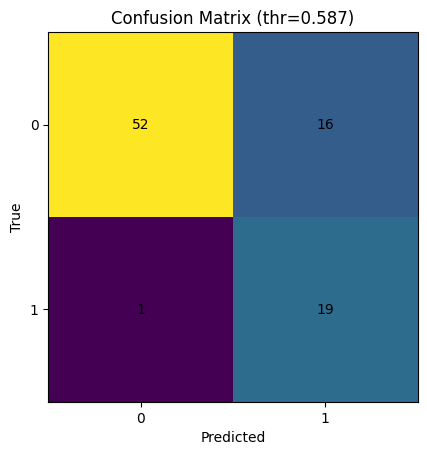

Saved: /content/work_oasis/outputs/confusion_matrix_best_threshold.png


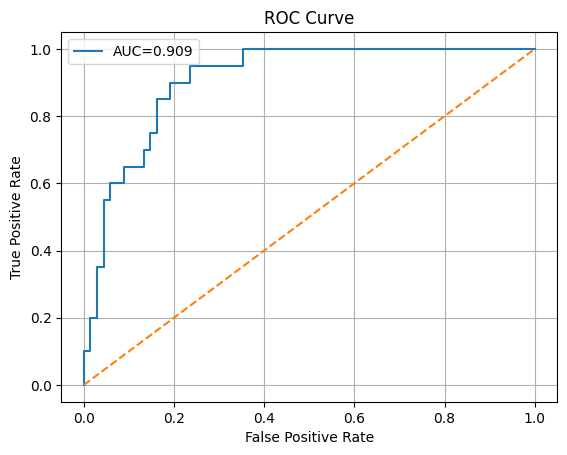

Saved: /content/work_oasis/outputs/roc_curve.png


{'threshold': 0.5866856575012207,
 'auc': 0.9088235294117646,
 'acc': 0.8068181818181818,
 'precision': 0.5428571428571428,
 'recall': 0.95,
 'f1': 0.6909090909090909,
 'cm': array([[52, 16],
        [ 1, 19]])}

In [17]:
# --- Evaluation + Best-threshold confusion matrix + ROC + saving artifacts ---
# Paste this as ONE cell (after you have: model, device, val_loader, OUT_DIR, and best_model already loaded)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc as sk_auc,
    roc_auc_score, accuracy_score, precision_recall_fscore_support
)

def eval_best_threshold(model, val_loader, device, out_dir, force_threshold=None):
    model.eval()
    y_true, y_prob = [], []

    # 1) Collect probabilities
    with torch.no_grad():
        for batch in val_loader:
            x = batch["image"].to(device)
            y = batch["label"].long().to(device)
            with torch.amp.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
                logits = model(x)
                prob1 = torch.softmax(logits, dim=1)[:, 1]
            y_true.extend(y.detach().cpu().numpy().tolist())
            y_prob.extend(prob1.detach().cpu().numpy().tolist())

    y_true = np.array(y_true, dtype=int)
    y_prob = np.array(y_prob, dtype=float)

    # 2) AUC (threshold-free)
    auc_val = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else float("nan")

    # 3) Choose threshold
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    if force_threshold is None:
        j = tpr - fpr  # Youden's J
        best_idx = int(np.argmax(j))
        best_thr = float(thr[best_idx])
        thr_name = "Youden"
    else:
        best_thr = float(force_threshold)
        thr_name = "Forced"

    # 4) Predictions with chosen threshold
    y_pred = (y_prob >= best_thr).astype(int)

    acc_val = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred)

    print(f"Threshold ({thr_name}) = {best_thr:.4f}")
    print(f"AUC={auc_val:.3f}  ACC={acc_val:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}")
    print("Confusion matrix:\n", cm)

    # 5) Save predictions
    os.makedirs(out_dir, exist_ok=True)
    pred_df = pd.DataFrame({"y_true": y_true, "y_prob": y_prob, "y_pred": y_pred})
    pred_path = os.path.join(out_dir, "val_predictions_best_threshold.csv")
    pred_df.to_csv(pred_path, index=False)
    print("Saved:", pred_path)

    # 6) Plot & save confusion matrix
    plt.figure()
    plt.imshow(cm)
    plt.title(f"Confusion Matrix (thr={best_thr:.3f})")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.xticks([0, 1]); plt.yticks([0, 1])
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    cm_path = os.path.join(out_dir, "confusion_matrix_best_threshold.png")
    plt.savefig(cm_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", cm_path)

    # 7) Plot & save ROC
    roc_auc_val = sk_auc(fpr, tpr)
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={roc_auc_val:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True)
    roc_path = os.path.join(out_dir, "roc_curve.png")
    plt.savefig(roc_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", roc_path)

    return {
        "threshold": best_thr,
        "auc": float(auc_val),
        "acc": float(acc_val),
        "precision": float(prec),
        "recall": float(rec),
        "f1": float(f1),
        "cm": cm,
    }

# Run evaluation (auto threshold by default)
results = eval_best_threshold(model, val_loader, device, OUT_DIR)
results

In [18]:
import json, os

summary = {
    "best_threshold": float(results["threshold"]),
    "auc": float(results["auc"]),
    "acc": float(results["acc"]),
    "precision": float(results["precision"]),
    "recall": float(results["recall"]),
    "f1": float(results["f1"]),
    "cm": results["cm"].tolist(),
}

out_path = os.path.join(OUT_DIR, "eval_summary.json")
with open(out_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved:", out_path)
summary

Saved: /content/work_oasis/outputs/eval_summary.json


{'best_threshold': 0.5866856575012207,
 'auc': 0.9088235294117646,
 'acc': 0.8068181818181818,
 'precision': 0.5428571428571428,
 'recall': 0.95,
 'f1': 0.6909090909090909,
 'cm': [[52, 16], [1, 19]]}

In [19]:
print(df.columns.tolist())
print(df["ID"].head())

['ID', 'M/F', 'Hand', 'Age', 'Educ', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF', 'Delay', 'CDR_num', 'label', 'ID_norm']
0    OAS1_0001_MR1
1    OAS1_0002_MR1
2    OAS1_0003_MR1
3    OAS1_0004_MR1
4    OAS1_0005_MR1
Name: ID, dtype: object


x1 shape: (1, 1, 128, 128, 128) label: 1


Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  0%|          | 0/1000 [00:00<?, ?it/s]Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(se

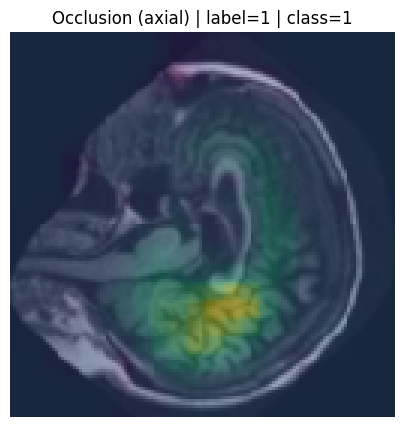

Saved: /content/work_oasis/outputs/occ_axial_z64.png


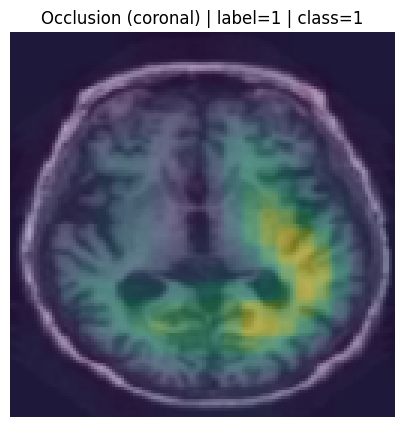

Saved: /content/work_oasis/outputs/occ_coronal_y64.png


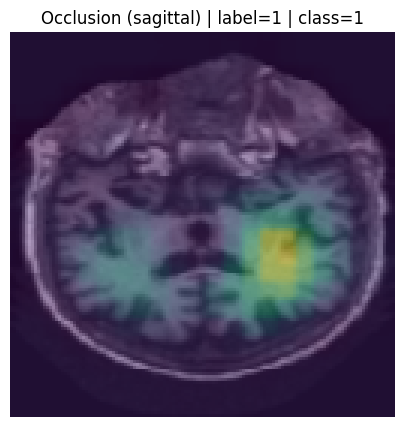

Saved: /content/work_oasis/outputs/occ_sagittal_x64.png
occ_map shape used: (128, 128, 128)
occ_logits shape: (1, 1, 128, 128, 128)


In [20]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from monai.visualize import OcclusionSensitivity

# 1) get one sample
batch = next(iter(val_loader))
x = batch["image"].to(device)      # (B,C,H,W,D)
y = batch["label"].long().cpu().numpy()

x1 = x[0:1]
y1 = int(y[0])
print("x1 shape:", tuple(x1.shape), "label:", y1)

# 2) run occlusion sensitivity (NO extra kwargs!)
model.eval()
occ = OcclusionSensitivity(nn_module=model, mask_size=(16, 16, 16), n_batch=8)

with torch.no_grad():
    occ_map, occ_logits = occ(x1)   # <-- returns (map, logits) in your version

# occ_map is usually (1, C, H, W, D) or (1, H, W, D) depending on MONAI version
occ_map = occ_map.detach().float().cpu()
img = x1.detach().float().cpu()[0, 0]  # (H,W,D)

# ---- choose channel for "positive class"
# If occ_map has a class/channel dimension, we take channel 1.
# If it doesn't, we just use it directly.
if occ_map.ndim == 5:
    # (B,C,H,W,D) -> pick class 1 if available, else class 0
    if occ_map.shape[1] > 1:
        occ_map = occ_map[0, 1]
        target_class = 1
    else:
        occ_map = occ_map[0, 0]
        target_class = 0
elif occ_map.ndim == 4:
    occ_map = occ_map[0]
    target_class = 1  # just for title
else:
    raise ValueError("Unexpected occ_map shape: " + str(tuple(occ_map.shape)))

# 3) normalize for overlay
img_np = img.numpy()
occ_np = occ_map.numpy()
occ_np = occ_np - occ_np.min()
if occ_np.max() > 0:
    occ_np = occ_np / occ_np.max()

H, W, D = img_np.shape
z = D // 2
yidx = W // 2
xidx = H // 2

def save_overlay(name, base2d, heat2d, fname):
    plt.figure(figsize=(6, 5))
    plt.imshow(base2d, cmap="gray")
    plt.imshow(heat2d, alpha=0.45)
    plt.title(f"Occlusion ({name}) | label={y1} | class={target_class}")
    plt.axis("off")
    path = os.path.join(OUT_DIR, fname)
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

save_overlay("axial",    img_np[:, :, z],    occ_np[:, :, z],    f"occ_axial_z{z}.png")
save_overlay("coronal",  img_np[:, yidx, :], occ_np[:, yidx, :], f"occ_coronal_y{yidx}.png")
save_overlay("sagittal", img_np[xidx, :, :], occ_np[xidx, :, :], f"occ_sagittal_x{xidx}.png")

print("occ_map shape used:", occ_np.shape)
print("occ_logits shape:", tuple(occ_logits.detach().cpu().shape))

Best slices -> axial z: 85 | coronal y: 73 | sagittal x: 91


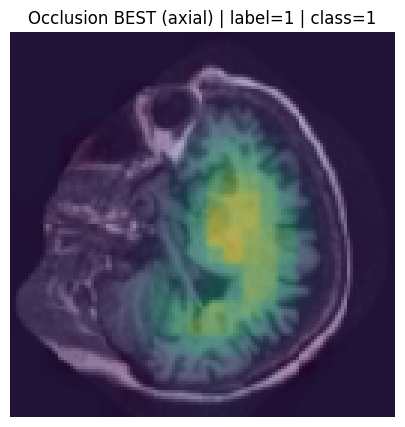

Saved: /content/work_oasis/outputs/occBEST_axial_z85.png


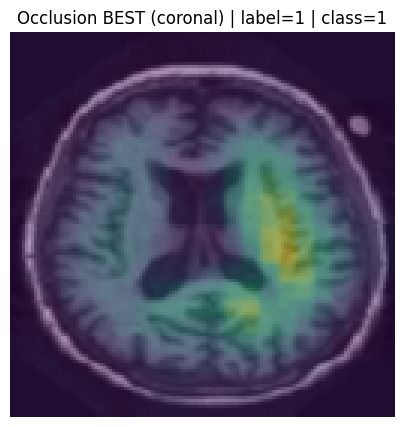

Saved: /content/work_oasis/outputs/occBEST_coronal_y73.png


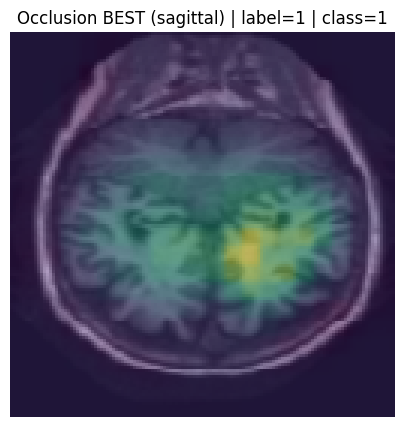

Saved: /content/work_oasis/outputs/occBEST_sagittal_x91.png


In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt

H, W, D = occ_np.shape

best_z = int(np.argmax([occ_np[:, :, z].mean() for z in range(D)]))  # axial
best_y = int(np.argmax([occ_np[:, y, :].mean() for y in range(W)]))  # coronal
best_x = int(np.argmax([occ_np[x, :, :].mean() for x in range(H)]))  # sagittal

print("Best slices -> axial z:", best_z, "| coronal y:", best_y, "| sagittal x:", best_x)

def save_overlay(name, base2d, heat2d, fname):
    plt.figure(figsize=(6, 5))
    plt.imshow(base2d, cmap="gray")
    plt.imshow(heat2d, alpha=0.45)
    plt.title(f"Occlusion BEST ({name}) | label={y1} | class={target_class}")
    plt.axis("off")
    path = os.path.join(OUT_DIR, fname)
    plt.savefig(path, dpi=250, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

save_overlay("axial",    img_np[:, :, best_z],   occ_np[:, :, best_z],   f"occBEST_axial_z{best_z}.png")
save_overlay("coronal",  img_np[:, best_y, :],   occ_np[:, best_y, :],   f"occBEST_coronal_y{best_y}.png")
save_overlay("sagittal", img_np[best_x, :, :],   occ_np[best_x, :, :],   f"occBEST_sagittal_x{best_x}.png")

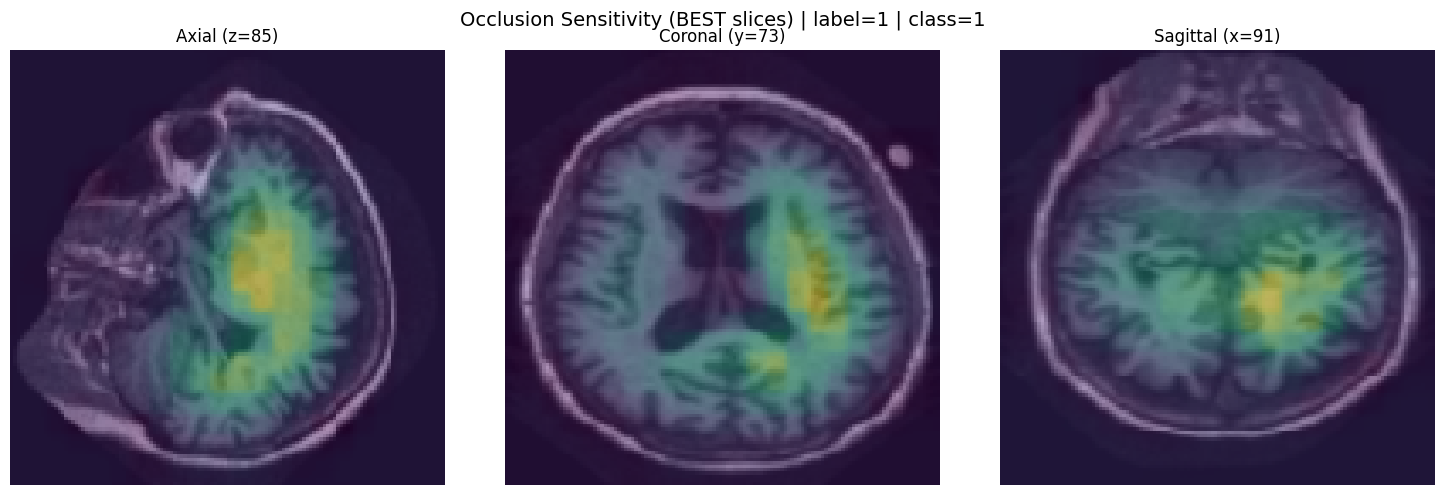

Saved combined figure: /content/work_oasis/outputs/occBEST_combined_x91_y73_z85.png


In [22]:
import os
import matplotlib.pyplot as plt

# Combined 3-view figure (best slices)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Axial
axes[0].imshow(img_np[:, :, best_z], cmap="gray")
axes[0].imshow(occ_np[:, :, best_z], alpha=0.45)
axes[0].set_title(f"Axial (z={best_z})")
axes[0].axis("off")

# Coronal
axes[1].imshow(img_np[:, best_y, :], cmap="gray")
axes[1].imshow(occ_np[:, best_y, :], alpha=0.45)
axes[1].set_title(f"Coronal (y={best_y})")
axes[1].axis("off")

# Sagittal
axes[2].imshow(img_np[best_x, :, :], cmap="gray")
axes[2].imshow(occ_np[best_x, :, :], alpha=0.45)
axes[2].set_title(f"Sagittal (x={best_x})")
axes[2].axis("off")

fig.suptitle(f"Occlusion Sensitivity (BEST slices) | label={y1} | class={target_class}", fontsize=14)
plt.tight_layout()

out_path = os.path.join(OUT_DIR, f"occBEST_combined_x{best_x}_y{best_y}_z{best_z}.png")
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved combined figure:", out_path)

In [23]:
import os, glob
print("OUT_DIR =", OUT_DIR)
for f in sorted(glob.glob(os.path.join(OUT_DIR, "occ*.png"))):
    print(os.path.basename(f))

OUT_DIR = /content/work_oasis/outputs
occBEST_axial_z85.png
occBEST_combined_x91_y73_z85.png
occBEST_coronal_y73.png
occBEST_sagittal_x91.png
occ_axial_z64.png
occ_coronal_y64.png
occ_sagittal_x64.png


Found negative sample: True


100%|██████████| 1000/1000 [00:52<00:00, 19.20it/s]


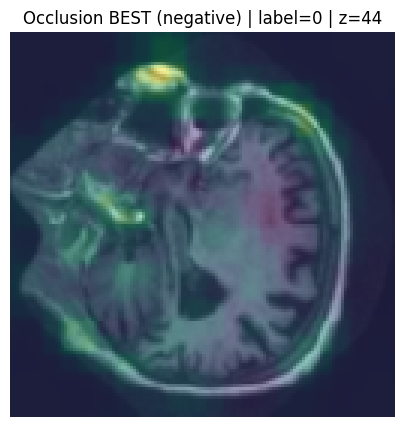

Saved: /content/work_oasis/outputs/occBEST_negative_axial_z44.png


In [24]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from monai.visualize import OcclusionSensitivity

# find a negative sample
x0 = None
y0 = None
for b in val_loader:
    yy = b["label"].long().cpu().numpy()
    idxs = np.where(yy == 0)[0]
    if len(idxs) > 0:
        i = int(idxs[0])
        x0 = b["image"][i:i+1].to(device)
        y0 = 0
        break

print("Found negative sample:", x0 is not None)

model.eval()
occ = OcclusionSensitivity(nn_module=model, mask_size=(16,16,16), n_batch=8)

with torch.no_grad():
    occ_map0, _ = occ(x0)

occ_map0 = occ_map0.detach().float().cpu()
if occ_map0.ndim == 5:
    occ_map0 = occ_map0[0, 0]
else:
    occ_map0 = occ_map0[0]

img0 = x0.detach().float().cpu()[0,0].numpy()
heat0 = occ_map0.numpy()
heat0 = heat0 - heat0.min()
if heat0.max() > 0:
    heat0 = heat0 / heat0.max()

H,W,D = heat0.shape
z_lo, z_hi = int(0.2*D), int(0.8*D)
best_z0 = z_lo + int(np.argmax([heat0[:, :, z].mean() for z in range(z_lo, z_hi)]))

plt.figure(figsize=(6,5))
plt.imshow(img0[:,:,best_z0], cmap="gray")
plt.imshow(heat0[:,:,best_z0], alpha=0.45)
plt.title(f"Occlusion BEST (negative) | label=0 | z={best_z0}")
plt.axis("off")

outp = os.path.join(OUT_DIR, f"occBEST_negative_axial_z{best_z0}.png")
plt.savefig(outp, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", outp)

In [25]:
import os, glob, json
import pandas as pd
from datetime import datetime

# ------------- helpers -------------
def safe_float(x):
    try:
        return float(x)
    except Exception:
        return None

# ------------- collect what we have -------------
# Try to reuse existing variables if they exist
summary = {
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "task": "Cognitive impairment detection (proxy) using OASIS cross-sectional; label = (CDR > 0)",
    "dataset": "OASIS cross-sectional",
    "model": "MONAI DenseNet121 (3D), in_channels=1, out_channels=2",
    "out_dir": OUT_DIR,
}

# Pull best checkpoint info if available
best_model_path = os.path.join(OUT_DIR, "best_model.pt")
summary["best_model_path"] = best_model_path if os.path.exists(best_model_path) else None

# If you computed threshold metrics dict earlier, reuse it
# (you printed something like {'threshold':..., 'auc':..., 'acc':..., 'precision':..., 'recall':..., 'f1':..., 'cm':...})
if "metrics" in globals() and isinstance(metrics, dict):
    summary.update({
        "threshold": safe_float(metrics.get("threshold")),
        "val_auc": safe_float(metrics.get("auc")),
        "val_acc": safe_float(metrics.get("acc")),
        "precision": safe_float(metrics.get("precision")),
        "recall": safe_float(metrics.get("recall")),
        "f1": safe_float(metrics.get("f1")),
        "confusion_matrix": metrics.get("cm"),
    })
else:
    # fallback to common variable names if present
    for k, v in [
        ("val_auc", "val_auc"),
        ("val_acc", "val_acc"),
        ("threshold", "best_thr"),
        ("precision", "prec"),
        ("recall", "rec"),
        ("f1", "f1"),
    ]:
        if v in globals():
            summary[k] = safe_float(globals()[v])

# ------------- save summary files -------------
os.makedirs(OUT_DIR, exist_ok=True)

json_path = os.path.join(OUT_DIR, "metrics_summary.json")
with open(json_path, "w") as f:
    json.dump(summary, f, indent=2)
print("Saved:", json_path)

# CSV version (1-row)
csv_path = os.path.join(OUT_DIR, "metrics_summary.csv")
flat = summary.copy()
# flatten confusion matrix if exists
cm = flat.pop("confusion_matrix", None)
if isinstance(cm, (list, tuple)) or hasattr(cm, "shape"):
    try:
        import numpy as np
        cm = np.array(cm).tolist()
    except Exception:
        pass
flat["cm_00"] = cm[0][0] if isinstance(cm, list) else None
flat["cm_01"] = cm[0][1] if isinstance(cm, list) else None
flat["cm_10"] = cm[1][0] if isinstance(cm, list) else None
flat["cm_11"] = cm[1][1] if isinstance(cm, list) else None
pd.DataFrame([flat]).to_csv(csv_path, index=False)
print("Saved:", csv_path)

# ------------- manifest (everything in OUT_DIR) -------------
manifest_path = os.path.join(OUT_DIR, "outputs_manifest.txt")
files = sorted(glob.glob(os.path.join(OUT_DIR, "*")))
with open(manifest_path, "w") as f:
    for p in files:
        f.write(os.path.basename(p) + "\n")
print("Saved:", manifest_path)

# ------------- verify key artifacts -------------
expected = [
    "best_model.pt",
    "training_history.csv",
    "curve_train_loss.png",
    "curve_val_auc.png",
    "curve_val_acc.png",
    "confusion_matrix_best_threshold.png",
    "roc_curve.png",
    # interpretability (at least one combined + one negative)
    # names may vary, we check patterns
]
missing = [x for x in expected if not os.path.exists(os.path.join(OUT_DIR, x))]
print("\n=== CHECKLIST ===")
print("OUT_DIR:", OUT_DIR)
print("Missing exact-name files:", missing)

# Pattern checks
patterns = {
    "occlusion_combined": "occBEST_combined*.png",
    "occlusion_negative": "occBEST_negative*.png",
    "occlusion_positive": "occBEST_*axial*.png",
}
print("\n=== PATTERN CHECKS ===")
for name, pat in patterns.items():
    hits = sorted(glob.glob(os.path.join(OUT_DIR, pat)))
    print(f"{name}: {len(hits)} file(s)")
    if hits:
        print("  example:", os.path.basename(hits[0]))

# ------------- nice report text -------------
print("\n=== REPORT SUMMARY (copy/paste) ===")
print(f"Task: {summary['task']}")
if summary.get("val_auc") is not None: print(f"Validation AUC: {summary['val_auc']:.3f}")
if summary.get("val_acc") is not None: print(f"Validation Accuracy: {summary['val_acc']:.3f}")
if summary.get("threshold") is not None: print(f"Best threshold (Youden): {summary['threshold']:.3f}")
if summary.get("precision") is not None: print(f"Precision: {summary['precision']:.3f}")
if summary.get("recall") is not None: print(f"Recall: {summary['recall']:.3f}")
if summary.get("f1") is not None: print(f"F1: {summary['f1']:.3f}")
print("Artifacts saved to:", OUT_DIR)

Saved: /content/work_oasis/outputs/metrics_summary.json
Saved: /content/work_oasis/outputs/metrics_summary.csv
Saved: /content/work_oasis/outputs/outputs_manifest.txt

=== CHECKLIST ===
OUT_DIR: /content/work_oasis/outputs
Missing exact-name files: []

=== PATTERN CHECKS ===
occlusion_combined: 1 file(s)
  example: occBEST_combined_x91_y73_z85.png
occlusion_negative: 1 file(s)
  example: occBEST_negative_axial_z44.png
occlusion_positive: 2 file(s)
  example: occBEST_axial_z85.png

=== REPORT SUMMARY (copy/paste) ===
Task: Cognitive impairment detection (proxy) using OASIS cross-sectional; label = (CDR > 0)
Artifacts saved to: /content/work_oasis/outputs


In [26]:
!zip -r oasis_results.zip /content/work_oasis/outputs

  adding: content/work_oasis/outputs/ (stored 0%)
  adding: content/work_oasis/outputs/occ_axial_z64.png (deflated 11%)
  adding: content/work_oasis/outputs/curve_val_auc.png (deflated 10%)
  adding: content/work_oasis/outputs/outputs_manifest.txt (deflated 51%)
  adding: content/work_oasis/outputs/occBEST_axial_z85.png (deflated 15%)
  adding: content/work_oasis/outputs/README_results.txt (deflated 20%)
  adding: content/work_oasis/outputs/occBEST_sagittal_x91.png (deflated 14%)
  adding: content/work_oasis/outputs/roc_curve.png (deflated 11%)
  adding: content/work_oasis/outputs/occBEST_negative_axial_z44.png (deflated 18%)
  adding: content/work_oasis/outputs/occBEST_coronal_y73.png (deflated 13%)
  adding: content/work_oasis/outputs/metrics_summary.csv (deflated 32%)
  adding: content/work_oasis/outputs/curve_train_loss.png (deflated 12%)
  adding: content/work_oasis/outputs/occ_sagittal_x64.png (deflated 11%)
  adding: content/work_oasis/outputs/curve_val_acc.png (deflated 10%)
  

In [27]:
from google.colab import files
files.download("oasis_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [37]:
import zipfile
from pathlib import Path

ZIP_PATH = Path("/content/drive/MyDrive/Internship_MONAI/data_zips/ds005892-main.zip")
EXTRACT_DIR = Path("/content/ds005892")

assert ZIP_PATH.exists(), f"Zip file not found: {ZIP_PATH}"

# extract only once
if not EXTRACT_DIR.exists():
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    print("Extracted to:", EXTRACT_DIR)
else:
    print("Already extracted:", EXTRACT_DIR)

print("Top-level items:", [p.name for p in EXTRACT_DIR.iterdir()][:10])

Already extracted: /content/ds005892
Top-level items: ['ds005892-main']


In [38]:
from pathlib import Path

base = Path("/content/ds005892")

for p in base.iterdir():
    print(p)

/content/ds005892/ds005892-main


In [39]:
# ===== PD (OpenNeuro ds005892) CONFIG =====
import os, glob, random
import numpy as np
import pandas as pd
from pathlib import Path

PD_PROJECT_DIR = Path("/content/work_pd_ds005892")
PD_OUT_DIR = PD_PROJECT_DIR / "outputs"
PD_OUT_DIR.mkdir(parents=True, exist_ok=True)

# IMPORTANT: set this to where YOU uploaded ds005892 on Colab (or Google Drive)
# Example 1 (Colab upload): "/content/ds005892"
# Example 2 (Drive): "/content/drive/MyDrive/datasets/ds005892"
PD_DATA_ROOT = Path("/content/drive/MyDrive/Internship_MONAI/data_zips/ds005892-download")

PD_CFG = {
    "project_name": "PD_ds005892_T1w_binary_PD_vs_Control",
    "seed": 42,
    "img_size": (128, 128, 128),
    "batch_size": 2,
    "num_workers": 2,
    "max_epochs": 10,
    "lr": 1e-4,
    "weight_decay": 1e-5,
    "out_dir": str(PD_OUT_DIR),
}

print("PD_DATA_ROOT:", PD_DATA_ROOT)
print("PD_OUT_DIR:", PD_OUT_DIR)

PD_DATA_ROOT: /content/drive/MyDrive/Internship_MONAI/data_zips/ds005892-download
PD_OUT_DIR: /content/work_pd_ds005892/outputs


In [40]:
# ===== PD (ds005892) INDEXING =====

participants_tsv = PD_DATA_ROOT / "participants.tsv"
assert participants_tsv.exists(), f"Missing: {participants_tsv}"

PD_part = pd.read_csv(participants_tsv, sep="\t")
print("participants columns:", PD_part.columns.tolist())
print(PD_part.head())

# Normalize group labels
PD_part["group"] = PD_part["group"].astype(str).str.strip()

def make_label(g):
    if g.lower() == "control":
        return 0
    if g.upper().startswith("PD"):
        return 1
    return None

PD_part["label"] = PD_part["group"].apply(make_label)
PD_part = PD_part.dropna(subset=["label"]).copy()
PD_part["label"] = PD_part["label"].astype(int)

print("Group counts:")
print(PD_part["group"].value_counts())
print("Label counts:", PD_part["label"].value_counts().to_dict())

participants columns: ['participant_id', 'group', 'age', 'sex']
  participant_id    group  age sex
0     sub-MJF001   PD-MCI   68   M
1     sub-MJF002   PD-MCI   67   M
2     sub-MJF003  Control   68   M
3     sub-MJF006  Control   75   M
4     sub-MJF007   PD-MCI   77   M
Group counts:
group
Control    22
PD-NC      18
PD-MCI     15
Name: count, dtype: int64
Label counts: {1: 33, 0: 22}


In [41]:
# ===== find T1w NIfTI files =====
# We use anatomical T1w: sub-*/anat/*_T1w.nii.gz

records = []
missing = 0

for _, row in PD_part.iterrows():
    sub = row["participant_id"]
    label = int(row["label"])

    candidates = sorted(glob.glob(str(PD_DATA_ROOT / sub / "anat" / f"{sub}_T1w.nii.gz")))
    if len(candidates) == 0:
        missing += 1
        continue

    records.append({
        "image": candidates[0],
        "label": label,
        "subject": sub,
        "group": row["group"],
        "age": row.get("age", None),
        "sex": row.get("sex", None),
    })

print("Found records:", len(records), "| missing T1w:", missing)
assert len(records) > 10, "Too few T1w files found — check PD_DATA_ROOT path."

PD_df = pd.DataFrame(records)
PD_df.to_csv(PD_OUT_DIR / "pd_index.csv", index=False)
print("Saved:", PD_OUT_DIR / "pd_index.csv")
PD_df.head()

Found records: 55 | missing T1w: 0
Saved: /content/work_pd_ds005892/outputs/pd_index.csv


,image,label,subject,group,age,sex
0,/content/drive/MyDrive/Internship_MONAI/data_z...,1,sub-MJF001,PD-MCI,68,M
1,/content/drive/MyDrive/Internship_MONAI/data_z...,1,sub-MJF002,PD-MCI,67,M
2,/content/drive/MyDrive/Internship_MONAI/data_z...,0,sub-MJF003,Control,68,M
3,/content/drive/MyDrive/Internship_MONAI/data_z...,0,sub-MJF006,Control,75,M
4,/content/drive/MyDrive/Internship_MONAI/data_z...,1,sub-MJF007,PD-MCI,77,M


In [42]:
from sklearn.model_selection import train_test_split

PD_train_df, PD_val_df = train_test_split(
    PD_df,
    test_size=0.2,
    random_state=PD_CFG["seed"],
    stratify=PD_df["label"],
)

print("Train:", len(PD_train_df), "Val:", len(PD_val_df))
print("Train label dist:", PD_train_df["label"].value_counts().to_dict())
print("Val label dist:", PD_val_df["label"].value_counts().to_dict())

PD_train_files = PD_train_df[["image", "label"]].to_dict("records")
PD_val_files   = PD_val_df[["image", "label"]].to_dict("records")

Train: 44 Val: 11
Train label dist: {1: 26, 0: 18}
Val label dist: {1: 7, 0: 4}


In [43]:
# ===== PD transforms + datasets + loaders =====

import torch
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    Orientationd,
    Spacingd,
    ScaleIntensityRanged,
    CropForegroundd,
    ResizeWithPadOrCropd,
    RandFlipd,
    RandAffined,
    EnsureTyped,
)
from monai.data import Dataset, DataLoader

PD_train_tfms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    Spacingd(keys=["image"], pixdim=(1.5, 1.5, 1.5), mode=("bilinear")),
    ScaleIntensityRanged(
        keys=["image"],
        a_min=0,
        a_max=2000,
        b_min=0.0,
        b_max=1.0,
        clip=True,
    ),
    CropForegroundd(keys=["image"], source_key="image"),
    ResizeWithPadOrCropd(keys=["image"], spatial_size=PD_CFG["img_size"]),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image"], prob=0.5, spatial_axis=2),
    RandAffined(
        keys=["image"],
        prob=0.3,
        rotate_range=(0.05, 0.05, 0.05),
        translate_range=(5, 5, 5),
        scale_range=(0.05, 0.05, 0.05),
    ),
    EnsureTyped(keys=["image", "label"]),
])

PD_val_tfms = Compose([
    LoadImaged(keys=["image"]),
    EnsureChannelFirstd(keys=["image"]),
    Orientationd(keys=["image"], axcodes="RAS"),
    Spacingd(keys=["image"], pixdim=(1.5, 1.5, 1.5), mode=("bilinear")),
    ScaleIntensityRanged(
        keys=["image"],
        a_min=0,
        a_max=2000,
        b_min=0.0,
        b_max=1.0,
        clip=True,
    ),
    CropForegroundd(keys=["image"], source_key="image"),
    ResizeWithPadOrCropd(keys=["image"], spatial_size=PD_CFG["img_size"]),
    EnsureTyped(keys=["image", "label"]),
])

PD_train_ds = Dataset(data=PD_train_files, transform=PD_train_tfms)
PD_val_ds   = Dataset(data=PD_val_files, transform=PD_val_tfms)

PD_train_loader = DataLoader(
    PD_train_ds,
    batch_size=PD_CFG["batch_size"],
    shuffle=True,
    num_workers=PD_CFG["num_workers"],
)

PD_val_loader = DataLoader(
    PD_val_ds,
    batch_size=1,
    shuffle=False,
    num_workers=PD_CFG["num_workers"],
)

print("PD loaders ready.")
print("Train batches:", len(PD_train_loader))
print("Val batches:", len(PD_val_loader))

PD loaders ready.
Train batches: 22
Val batches: 11


monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


In [44]:
# ===== PD loader sanity check =====

first_batch = next(iter(PD_train_loader))
print("Keys:", first_batch.keys())
print("Image shape:", first_batch["image"].shape)
print("Label shape:", first_batch["label"].shape)
print("Labels:", first_batch["label"])

Keys: dict_keys(['image', 'label', 'foreground_start_coord', 'foreground_end_coord'])
Image shape: torch.Size([2, 1, 128, 128, 128])
Label shape: torch.Size([2])
Labels: metatensor([1, 0])


In [46]:
# ===== PD model + training =====

import torch
import torch.nn as nn
from monai.networks.nets import DenseNet121
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

PD_model = DenseNet121(
    spatial_dims=3,
    in_channels=1,
    out_channels=2
).to(device)

# class weights from train split
pd_train_labels = [d["label"] for d in PD_train_files]
pd_pos = sum(pd_train_labels)
pd_neg = len(pd_train_labels) - pd_pos

w0 = 1.0 / max(pd_neg, 1)
w1 = 1.0 / max(pd_pos, 1)
PD_class_weights = torch.tensor([w0, w1], dtype=torch.float32).to(device)

print("Train counts:", {0: pd_neg, 1: pd_pos}, "weights:", PD_class_weights.detach().cpu().numpy())

PD_loss_fn = nn.CrossEntropyLoss(weight=PD_class_weights)
PD_optimizer = torch.optim.AdamW(
    PD_model.parameters(),
    lr=PD_CFG["lr"],
    weight_decay=PD_CFG["weight_decay"]
)

PD_scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

def pd_run_eval():
    PD_model.eval()
    y_true, y_prob, y_pred = [], [], []

    with torch.no_grad():
        for batch in PD_val_loader:
            x = batch["image"].to(device)
            y = batch["label"].long().to(device)

            with torch.amp.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
                logits = PD_model(x)
                prob1 = torch.softmax(logits, dim=1)[:, 1]
                pred = torch.argmax(logits, dim=1)

            y_true.extend(y.detach().cpu().numpy().tolist())
            y_prob.extend(prob1.detach().cpu().numpy().tolist())
            y_pred.extend(pred.detach().cpu().numpy().tolist())

    auc = roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else float("nan")
    acc = (np.array(y_true) == np.array(y_pred)).mean()
    return auc, acc

PD_history = {"epoch": [], "train_loss": [], "val_auc": [], "val_acc": []}

PD_best_auc = -1.0
PD_best_path = PD_OUT_DIR / "best_model_pd.pt"

for epoch in range(1, PD_CFG["max_epochs"] + 1):
    PD_model.train()
    epoch_loss = 0.0

    pbar = tqdm(PD_train_loader, desc=f"[PD] Epoch {epoch}/{PD_CFG['max_epochs']}")
    for batch in pbar:
        x = batch["image"].to(device)
        y = batch["label"].long().to(device)

        PD_optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
            logits = PD_model(x)
            loss = PD_loss_fn(logits, y)

        PD_scaler.scale(loss).backward()
        PD_scaler.step(PD_optimizer)
        PD_scaler.update()

        epoch_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = epoch_loss / max(1, len(PD_train_loader))
    val_auc, val_acc = pd_run_eval()

    PD_history["epoch"].append(epoch)
    PD_history["train_loss"].append(float(avg_loss))
    PD_history["val_auc"].append(float(val_auc) if val_auc == val_auc else float("nan"))
    PD_history["val_acc"].append(float(val_acc))

    print(f"[PD Epoch {epoch}] loss={avg_loss:.4f} val_auc={val_auc:.4f} val_acc={val_acc:.4f}")

    if val_auc == val_auc and val_auc > PD_best_auc:
        PD_best_auc = val_auc
        torch.save(
            {
                "model": PD_model.state_dict(),
                "epoch": int(epoch),
                "val_auc": float(val_auc),
            },
            PD_best_path,
        )
        print("Saved best:", PD_best_path)

print("Training finished. Best AUC:", PD_best_auc)

Device: cuda
Train counts: {0: 18, 1: 26} weights: [0.05555556 0.03846154]


[PD] Epoch 1/10: 100%|██████████| 22/22 [00:46<00:00,  2.11s/it, loss=0.4418]


[PD Epoch 1] loss=0.7087 val_auc=0.1786 val_acc=0.6364
Saved best: /content/work_pd_ds005892/outputs/best_model_pd.pt


[PD] Epoch 2/10: 100%|██████████| 22/22 [00:20<00:00,  1.07it/s, loss=0.5567]


[PD Epoch 2] loss=0.7163 val_auc=0.8571 val_acc=0.6364
Saved best: /content/work_pd_ds005892/outputs/best_model_pd.pt


...

[PD Epoch 8] loss=0.6799 val_auc=0.7500 val_acc=0.6364


[PD] Epoch 9/10: 100%|██████████| 22/22 [00:21<00:00,  1.05it/s, loss=1.1046]


[PD Epoch 9] loss=0.6253 val_auc=0.8929 val_acc=0.3636


[PD] Epoch 10/10: 100%|██████████| 22/22 [00:19<00:00,  1.11it/s, loss=0.6008]


[PD Epoch 10] loss=0.7027 val_auc=0.7143 val_acc=0.6364
Training finished. Best AUC: 0.8928571428571428


Saved: /content/work_pd_ds005892/outputs/pd_training_history.csv


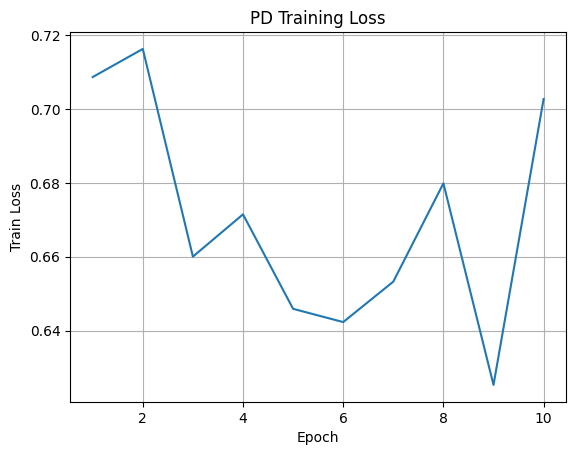

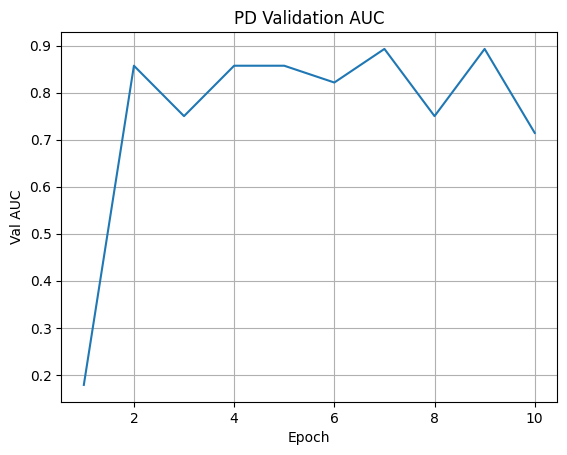

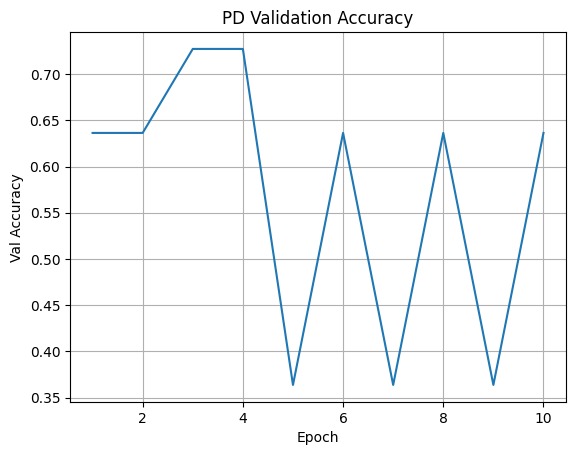

In [47]:
# ===== PD save curves =====

import pandas as pd
import matplotlib.pyplot as plt

PD_hist_df = pd.DataFrame(PD_history)
PD_hist_csv = PD_OUT_DIR / "pd_training_history.csv"
PD_hist_df.to_csv(PD_hist_csv, index=False)
print("Saved:", PD_hist_csv)

# train loss
plt.figure()
plt.plot(PD_hist_df["epoch"], PD_hist_df["train_loss"])
plt.xlabel("Epoch")
plt.ylabel("Train Loss")
plt.title("PD Training Loss")
plt.grid(True)
plt.savefig(PD_OUT_DIR / "pd_curve_train_loss.png", dpi=200, bbox_inches="tight")
plt.show()

# val auc
plt.figure()
plt.plot(PD_hist_df["epoch"], PD_hist_df["val_auc"])
plt.xlabel("Epoch")
plt.ylabel("Val AUC")
plt.title("PD Validation AUC")
plt.grid(True)
plt.savefig(PD_OUT_DIR / "pd_curve_val_auc.png", dpi=200, bbox_inches="tight")
plt.show()

# val acc
plt.figure()
plt.plot(PD_hist_df["epoch"], PD_hist_df["val_acc"])
plt.xlabel("Epoch")
plt.ylabel("Val Accuracy")
plt.title("PD Validation Accuracy")
plt.grid(True)
plt.savefig(PD_OUT_DIR / "pd_curve_val_acc.png", dpi=200, bbox_inches="tight")
plt.show()

Loaded best PD epoch: 7 best AUC: 0.8928571428571428

=== PD METRICS ===
AUC: 0.8928571428571428
ACC: 0.9090909090909091
Best threshold: 0.033557817339897156
Precision: 0.875
Recall: 1.0
F1: 0.9333333333333333
Confusion matrix:
 [[3 1]
 [0 7]]
Saved: /content/work_pd_ds005892/outputs/pd_val_predictions.csv
Saved: /content/work_pd_ds005892/outputs/pd_metrics_summary.json
Saved: /content/work_pd_ds005892/outputs/pd_metrics_summary.csv


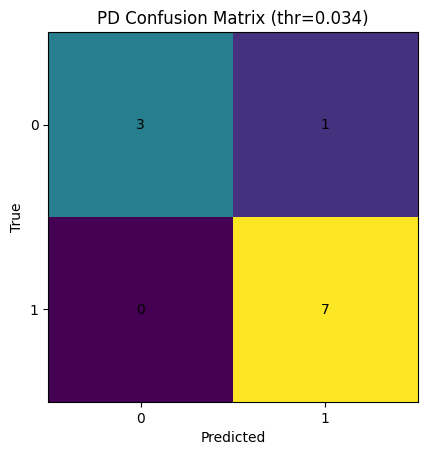

Saved: /content/work_pd_ds005892/outputs/pd_confusion_matrix.png


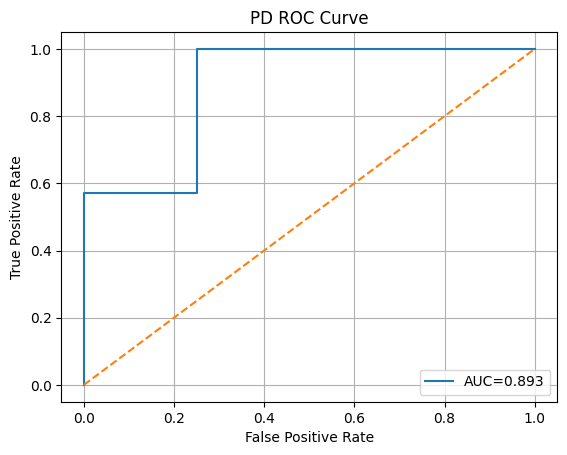

Saved: /content/work_pd_ds005892/outputs/pd_roc_curve.png


In [48]:
# ===== PD evaluation: confusion matrix + ROC + saved predictions =====

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc as sk_auc,
    roc_auc_score,
    accuracy_score,
    precision_recall_fscore_support,
)

# 1) load best checkpoint
pd_ckpt = torch.load(PD_best_path, map_location=device)
PD_model.load_state_dict(pd_ckpt["model"])
PD_model.eval()

print("Loaded best PD epoch:", pd_ckpt["epoch"], "best AUC:", pd_ckpt["val_auc"])

# 2) collect validation predictions
pd_y_true, pd_y_prob = [], []

with torch.no_grad():
    for batch in PD_val_loader:
        x = batch["image"].to(device)
        y = batch["label"].long().to(device)

        with torch.amp.autocast(device_type="cuda", enabled=torch.cuda.is_available()):
            logits = PD_model(x)
            prob1 = torch.softmax(logits, dim=1)[:, 1]

        pd_y_true.extend(y.detach().cpu().numpy().tolist())
        pd_y_prob.extend(prob1.detach().cpu().numpy().tolist())

pd_y_true = np.array(pd_y_true, dtype=int)
pd_y_prob = np.array(pd_y_prob, dtype=float)

# 3) best threshold by Youden J
pd_fpr, pd_tpr, pd_thr = roc_curve(pd_y_true, pd_y_prob)
pd_j = pd_tpr - pd_fpr
pd_best_idx = int(np.argmax(pd_j))
pd_best_thr = float(pd_thr[pd_best_idx])

pd_y_pred = (pd_y_prob >= pd_best_thr).astype(int)

# 4) metrics
pd_auc = float(roc_auc_score(pd_y_true, pd_y_prob)) if len(np.unique(pd_y_true)) > 1 else float("nan")
pd_acc = float(accuracy_score(pd_y_true, pd_y_pred))
pd_prec, pd_rec, pd_f1, _ = precision_recall_fscore_support(
    pd_y_true, pd_y_pred, average="binary", zero_division=0
)

pd_cm = confusion_matrix(pd_y_true, pd_y_pred)

print("\n=== PD METRICS ===")
print("AUC:", pd_auc)
print("ACC:", pd_acc)
print("Best threshold:", pd_best_thr)
print("Precision:", float(pd_prec))
print("Recall:", float(pd_rec))
print("F1:", float(pd_f1))
print("Confusion matrix:\n", pd_cm)

# 5) save predictions
pd_pred_path = PD_OUT_DIR / "pd_val_predictions.csv"
pd.DataFrame({
    "y_true": pd_y_true,
    "y_prob": pd_y_prob,
    "y_pred": pd_y_pred,
}).to_csv(pd_pred_path, index=False)
print("Saved:", pd_pred_path)

# 6) save metrics summary
pd_summary = {
    "task": "Parkinson vs Control using OpenNeuro ds005892 T1w MRI",
    "val_auc": pd_auc,
    "val_acc": pd_acc,
    "threshold_youden": pd_best_thr,
    "precision": float(pd_prec),
    "recall": float(pd_rec),
    "f1": float(pd_f1),
    "confusion_matrix": pd_cm.tolist(),
}

with open(PD_OUT_DIR / "pd_metrics_summary.json", "w") as f:
    json.dump(pd_summary, f, indent=2)

pd.DataFrame([{
    "task": pd_summary["task"],
    "val_auc": pd_summary["val_auc"],
    "val_acc": pd_summary["val_acc"],
    "threshold_youden": pd_summary["threshold_youden"],
    "precision": pd_summary["precision"],
    "recall": pd_summary["recall"],
    "f1": pd_summary["f1"],
    "tn": int(pd_cm[0, 0]),
    "fp": int(pd_cm[0, 1]),
    "fn": int(pd_cm[1, 0]),
    "tp": int(pd_cm[1, 1]),
}]).to_csv(PD_OUT_DIR / "pd_metrics_summary.csv", index=False)

print("Saved:", PD_OUT_DIR / "pd_metrics_summary.json")
print("Saved:", PD_OUT_DIR / "pd_metrics_summary.csv")

# 7) confusion matrix plot
plt.figure()
plt.imshow(pd_cm)
plt.title(f"PD Confusion Matrix (thr={pd_best_thr:.3f})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0, 1])
plt.yticks([0, 1])
for (i, j), v in np.ndenumerate(pd_cm):
    plt.text(j, i, str(v), ha="center", va="center")
plt.savefig(PD_OUT_DIR / "pd_confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", PD_OUT_DIR / "pd_confusion_matrix.png")

# 8) ROC plot
plt.figure()
pd_roc_auc = float(sk_auc(pd_fpr, pd_tpr))
plt.plot(pd_fpr, pd_tpr, label=f"AUC={pd_roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("PD ROC Curve")
plt.legend()
plt.grid(True)
plt.savefig(PD_OUT_DIR / "pd_roc_curve.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", PD_OUT_DIR / "pd_roc_curve.png")

In [49]:
# ===== PD package results for download =====

import shutil
from google.colab import files

PD_ZIP = "/content/pd_results.zip"

shutil.make_archive(
    PD_ZIP.replace(".zip",""),
    'zip',
    PD_OUT_DIR
)

print("Created:", PD_ZIP)

files.download(PD_ZIP)

Created: /content/pd_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
!pip install captum

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 114.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
imagecodecs 2026.3.6 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have n

True label: 0


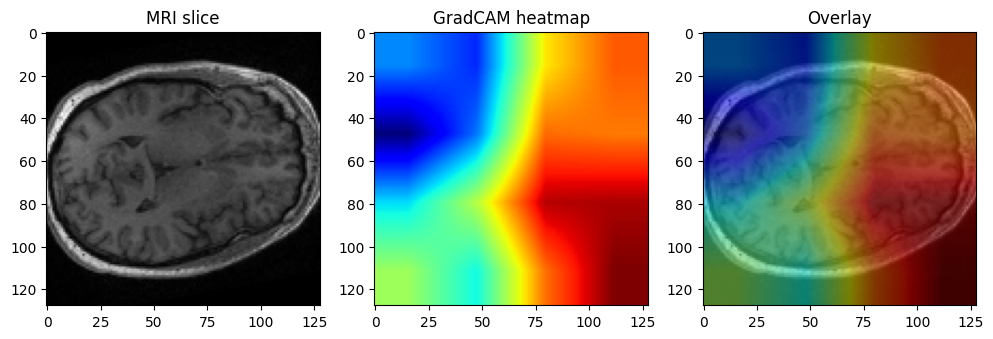

Saved: /content/work_pd_ds005892/outputs/pd_gradcam_example.png


In [51]:
# ===== PD Grad-CAM explainability =====

import torch
import matplotlib.pyplot as plt
import numpy as np

from monai.visualize import GradCAM

PD_model.eval()

# choose one validation sample
sample = next(iter(PD_val_loader))

image = sample["image"].to(device)
label = sample["label"].item()

print("True label:", label)

# choose last convolution layer
target_layer = "features.denseblock4"

cam = GradCAM(
    nn_module=PD_model,
    target_layers=target_layer,
)

heatmap = cam(x=image)

heatmap = heatmap.cpu().numpy()[0,0]
image_np = image.cpu().numpy()[0,0]

# take middle slice
z = image_np.shape[2] // 2

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(image_np[:,:,z], cmap="gray")
plt.title("MRI slice")

plt.subplot(1,3,2)
plt.imshow(heatmap[:,:,z], cmap="jet")
plt.title("GradCAM heatmap")

plt.subplot(1,3,3)
plt.imshow(image_np[:,:,z], cmap="gray")
plt.imshow(heatmap[:,:,z], cmap="jet", alpha=0.5)
plt.title("Overlay")

plt.savefig(PD_OUT_DIR / "pd_gradcam_example.png", dpi=200)
plt.show()

print("Saved:", PD_OUT_DIR / "pd_gradcam_example.png")

In [52]:
# ===== Generate multiple GradCAM examples =====

import os
from tqdm import tqdm

save_dir = PD_OUT_DIR / "gradcam_examples"
os.makedirs(save_dir, exist_ok=True)

cam = GradCAM(
    nn_module=PD_model,
    target_layers="features.denseblock4"
)

count = 0

for batch in PD_val_loader:

    image = batch["image"].to(device)
    label = batch["label"].item()

    heatmap = cam(x=image)

    heatmap = heatmap.cpu().numpy()[0,0]
    image_np = image.cpu().numpy()[0,0]

    z = image_np.shape[2] // 2

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(image_np[:,:,z], cmap="gray")
    plt.title("MRI")

    plt.subplot(1,3,2)
    plt.imshow(heatmap[:,:,z], cmap="jet")
    plt.title("GradCAM")

    plt.subplot(1,3,3)
    plt.imshow(image_np[:,:,z], cmap="gray")
    plt.imshow(heatmap[:,:,z], cmap="jet", alpha=0.5)
    plt.title("Overlay")

    path = save_dir / f"gradcam_{count}_label{label}.png"
    plt.savefig(path, dpi=200)
    plt.close()

    count += 1

    if count >= 10:
        break

print("Saved GradCAM examples to:", save_dir)

Saved GradCAM examples to: /content/work_pd_ds005892/outputs/gradcam_examples
